In [1]:
# This cell imports the libraries we need for working with NinaPro data.
# Think of libraries like "tools" we add to Python to do specific tasks.

# scipy.io: For loading .mat files (MATLAB format)
import scipy.io as sio

# numpy: For numerical operations (like arrays and math)
import numpy as np

# matplotlib.pyplot: For plotting graphs (to visualize EMG signals)
import matplotlib.pyplot as plt

In [2]:
# This cell loads the S1_A1_E1.mat file from your ninaprodb folder.

# Path to the file (adjust if your folder is named differently)
file_path = 'ninaprodb/s1/S1_A1_E1.mat'

# Load the .mat file into a variable called 'data'
data = sio.loadmat(file_path)

# Print all the "keys" (names of the data inside the file)
print("Keys in the .mat file:", data.keys())

Keys in the .mat file: dict_keys(['__header__', '__version__', '__globals__', 'emg', 'stimulus', 'glove', 'subject', 'exercise', 'repetition', 'restimulus', 'rerepetition'])


In [3]:
# Extract data with correct assumptions
emg = data['emg']  # Shape: (101014, 10) = (samples, electrodes)
restimulus = data['restimulus'].flatten()  # Shape: (101014,)
fs = 100  # Preprocessed to 100 Hz (from the paper)

print("EMG shape:", emg.shape)  # (101014, 10)
print("Restimulus shape:", restimulus.shape)
print("Sampling frequency:", fs, "Hz")
print("Unique gestures:", np.unique(restimulus))  # Should show 1-12

EMG shape: (101014, 10)
Restimulus shape: (101014,)
Sampling frequency: 100 Hz
Unique gestures: [ 0  1  2  3  4  5  6  7  8  9 10 11 12]


In [4]:
# Plot EMG for gesture 1 (Index Flexion)
gesture_id = 1
gesture_indices = np.where(restimulus == gesture_id)[0]

# Take first 200 samples (2 seconds at 100 Hz)
start_idx = gesture_indices[0]
end_idx = start_idx + 200

plt.figure(figsize=(12, 6))
for i in range(10):  # 10 electrodes
    plt.plot(emg[start_idx:end_idx, i], label=f'Electrode {i+1}')
plt.xlabel('Samples (at 100 Hz)')
plt.ylabel('EMG Amplitude')
plt.title(f'Preprocessed EMG for Gesture {gesture_id} (Index Flexion)')
plt.legend()
plt.grid()
plt.show()

<Figure size 1200x600 with 1 Axes>

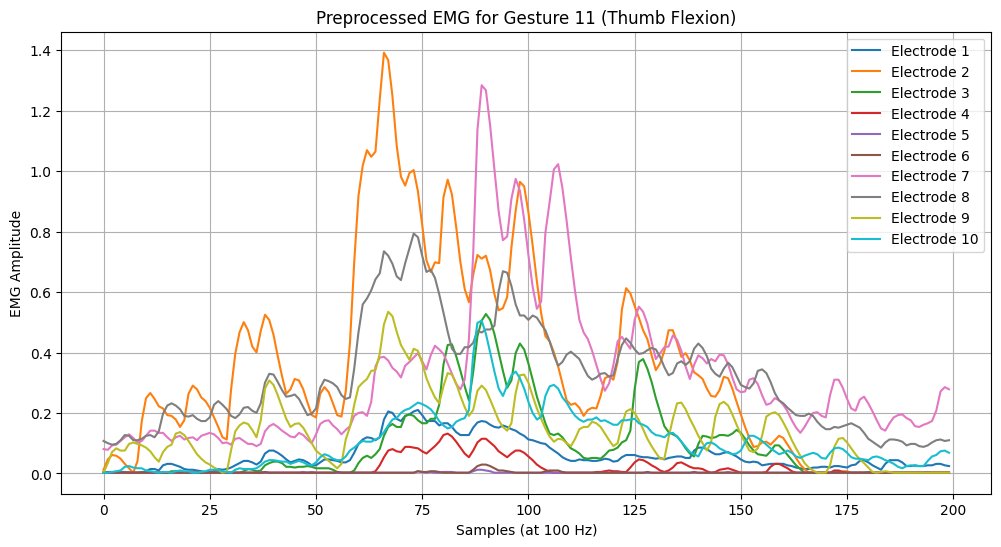

In [5]:
# Plot EMG for gesture 11 (Thumb Flexion)
gesture_id = 11
gesture_indices = np.where(restimulus == gesture_id)[0]

start_idx = gesture_indices[0]
end_idx = start_idx + 200

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.plot(emg[start_idx:end_idx, i], label=f'Electrode {i+1}')
plt.xlabel('Samples (at 100 Hz)')
plt.ylabel('EMG Amplitude')
plt.title(f'Preprocessed EMG for Gesture {gesture_id} (Thumb Flexion)')
plt.legend()
plt.grid()
plt.show()

In [6]:
# Print shapes of important arrays
print("emg shape:", data['emg'].shape)
print("stimulus shape:", data['stimulus'].shape)
print("subject:", data['subject'])
print("exercise:", data['exercise'])
print("repetition shape:", data['repetition'].shape)
print("restimulus shape:", data['restimulus'].shape)

emg shape: (101014, 10)
stimulus shape: (101014, 1)
subject: [[1]]
exercise: [[1]]
repetition shape: (101014, 1)
restimulus shape: (101014, 1)


In [7]:
import numpy as np

# Flatten the arrays (they are (n,1) shape)
stimulus = data['stimulus'].flatten()
restimulus = data['restimulus'].flatten()
repetition = data['repetition'].flatten()

# Print unique values
print("Unique gestures (stimulus):", np.unique(stimulus))
print("Unique repetitions:", np.unique(repetition))
print("Number of gesture starts (restimulus):", len(restimulus))
print("First 10 restimulus indices:", restimulus[:10])

Unique gestures (stimulus): [ 0  1  2  3  4  5  6  7  8  9 10 11 12]
Unique repetitions: [ 0  1  2  3  4  5  6  7  8  9 10]
Number of gesture starts (restimulus): 101014
First 10 restimulus indices: [0 0 0 0 0 0 0 0 0 0]


In [8]:
import numpy as np

# Flatten stimulus
stimulus = data['stimulus'].flatten()

# Find where stimulus changes (gesture starts)
# We compare each sample to the previous one
gesture_starts = np.where(np.diff(stimulus) != 0)[0] + 1  # +1 because diff shifts left

# Also include the very first sample (index 0)
gesture_starts = np.insert(gesture_starts, 0, 0)

print("Number of gesture starts:", len(gesture_starts))
print("First 20 start indices:", gesture_starts[:20])
print("Stimulus at start indices:", stimulus[gesture_starts[:20]])

Number of gesture starts: 241
First 20 start indices: [   0  333  849 1169 1685 2009 2526 2846 3358 3682 4198 4518 5030 5351
 5867 6195 6707 7027 7543 7863]
Stimulus at start indices: [0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1]


In [9]:
# Get stimulus at all start indices
gestures_at_starts = stimulus[gesture_starts]

print("All gestures at start indices:", np.unique(gestures_at_starts))
print("Count per gesture:")
for g in np.unique(gestures_at_starts):
    print(f"  Gesture {g}: {np.sum(gestures_at_starts == g)} times")

All gestures at start indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12]
Count per gesture:
  Gesture 0: 121 times
  Gesture 1: 10 times
  Gesture 2: 10 times
  Gesture 3: 10 times
  Gesture 4: 10 times
  Gesture 5: 10 times
  Gesture 6: 10 times
  Gesture 7: 10 times
  Gesture 8: 10 times
  Gesture 9: 10 times
  Gesture 10: 10 times
  Gesture 11: 10 times
  Gesture 12: 10 times


In [10]:
# Assume sampling rate is 2000 Hz (common in NinaDB)
fs = 2000  # samples per second

# Let's check the time between consecutive gesture starts
time_between_starts = np.diff(gesture_starts) / fs  # in seconds

print("Time between first 20 gesture starts (seconds):")
print(time_between_starts[:20])
print("\nAverage time between starts:", np.mean(time_between_starts), "seconds")
print("Min time:", np.min(time_between_starts), "seconds")
print("Max time:", np.max(time_between_starts), "seconds")

Time between first 20 gesture starts (seconds):
[0.1665 0.258  0.16   0.258  0.162  0.2585 0.16   0.256  0.162  0.258
 0.16   0.256  0.1605 0.258  0.164  0.256  0.16   0.258  0.16   0.258 ]

Average time between starts: 0.20976666666666663 seconds
Min time: 0.16 seconds
Max time: 0.262 seconds


In [11]:
fs = 100  # samples per second (as per NinaDB preprocessing)

# Recalculate time between starts
time_between_starts = np.diff(gesture_starts) / fs  # in seconds

print("Time between first 20 gesture starts (seconds) with fs=100Hz:")
print(time_between_starts[:20])
print("\nAverage time between starts:", np.mean(time_between_starts), "seconds")
print("Min time:", np.min(time_between_starts), "seconds")
print("Max time:", np.max(time_between_starts), "seconds")

Time between first 20 gesture starts (seconds) with fs=100Hz:
[3.33 5.16 3.2  5.16 3.24 5.17 3.2  5.12 3.24 5.16 3.2  5.12 3.21 5.16
 3.28 5.12 3.2  5.16 3.2  5.16]

Average time between starts: 4.195333333333334 seconds
Min time: 3.2 seconds
Max time: 5.24 seconds


In [12]:
print("Exercise value:", data['exercise'])
print("Subject value:", data['subject'])
print("Are there multiple exercises in this file?", "exercise" in data and len(data['exercise']) > 1)

Exercise value: [[1]]
Subject value: [[1]]
Are there multiple exercises in this file? False


In [13]:
# For each gesture start, how many samples until the next start?
samples_per_gesture = np.diff(gesture_starts)
print("Samples per segment (first 20):", samples_per_gesture[:20])
print("Average samples per segment:", np.mean(samples_per_gesture))

Samples per segment (first 20): [333 516 320 516 324 517 320 512 324 516 320 512 321 516 328 512 320 516
 320 516]
Average samples per segment: 419.53333333333336


In [14]:
# Get all start indices where stimulus is 1 (Gesture 1)
gesture_1_starts = gesture_starts[stimulus[gesture_starts] == 1]

# For each start, get the next start (end of this gesture)
# The next start is the next index in gesture_starts
# But we need to pair each start with the next one
gesture_1_ends = []
for i, start in enumerate(gesture_1_starts):
    # Find the next start index in gesture_starts that is > start
    next_idx = np.searchsorted(gesture_starts, start, side='right')
    if next_idx < len(gesture_starts):
        end = gesture_starts[next_idx]
        gesture_1_ends.append(end)
    else:
        # If no next start, use the end of the data
        gesture_1_ends.append(len(stimulus))

gesture_1_ends = np.array(gesture_1_ends)

# Now, for each Gesture 1, get the EMG window
emg = data['emg']  # (101014, 10)
gesture_1_windows = []
for start, end in zip(gesture_1_starts, gesture_1_ends):
    window = emg[start:end, :]  # (n_samples, 10)
    gesture_1_windows.append(window)
    print(f"Gesture 1 rep: start={start}, end={end}, duration={end-start} samples")

print(f"\nTotal Gesture 1 repetitions: {len(gesture_1_windows)}")
print(f"Average duration: {np.mean(gesture_1_ends - gesture_1_starts)} samples")

Gesture 1 rep: start=333, end=849, duration=516 samples
Gesture 1 rep: start=1169, end=1685, duration=516 samples
Gesture 1 rep: start=2009, end=2526, duration=517 samples
Gesture 1 rep: start=2846, end=3358, duration=512 samples
Gesture 1 rep: start=3682, end=4198, duration=516 samples
Gesture 1 rep: start=4518, end=5030, duration=512 samples
Gesture 1 rep: start=5351, end=5867, duration=516 samples
Gesture 1 rep: start=6195, end=6707, duration=512 samples
Gesture 1 rep: start=7027, end=7543, duration=516 samples
Gesture 1 rep: start=7863, end=8379, duration=516 samples

Total Gesture 1 repetitions: 10
Average duration: 514.9 samples


In [15]:
# For each gesture (1-12), get all start indices and durations
for g in range(1, 13):
    starts = gesture_starts[stimulus[gesture_starts] == g]
    ends = []
    for start in starts:
        next_idx = np.searchsorted(gesture_starts, start, side='right')
        end = gesture_starts[next_idx] if next_idx < len(gesture_starts) else len(stimulus)
        ends.append(end)
    ends = np.array(ends)
    durations = ends - starts
    print(f"Gesture {g}: {len(starts)} reps, durations (samples): {durations}, avg={np.mean(durations):.1f}")
    

Gesture 1: 10 reps, durations (samples): [516 516 517 512 516 512 516 512 516 516], avg=514.9
Gesture 2: 10 reps, durations (samples): [516 516 516 517 520 520 516 517 520 516], avg=517.4
Gesture 3: 10 reps, durations (samples): [516 516 516 516 517 516 516 516 513 516], avg=515.8
Gesture 4: 10 reps, durations (samples): [520 516 520 516 520 517 516 516 516 516], avg=517.3
Gesture 5: 10 reps, durations (samples): [516 516 516 524 516 516 517 516 516 520], avg=517.3
Gesture 6: 10 reps, durations (samples): [520 516 516 517 516 516 516 517 520 516], avg=517.0
Gesture 7: 10 reps, durations (samples): [516 517 520 516 516 521 516 516 516 517], avg=517.1
Gesture 8: 10 reps, durations (samples): [516 520 516 520 516 516 516 520 516 516], avg=517.2
Gesture 9: 10 reps, durations (samples): [512 513 516 516 516 513 512 512 512 513], avg=513.5
Gesture 10: 10 reps, durations (samples): [512 512 512 513 512 512 516 516 516 516], avg=513.7
Gesture 11: 10 reps, durations (samples): [516 516 516 516 

In [16]:
# Initialize lists to store features and labels
X = []  # will be (n_repetitions, 10)
y = []  # gesture labels (1-12)

# Loop over gestures 1-12
for g in range(1, 13):
    # Get all start indices for this gesture
    starts = gesture_starts[stimulus[gesture_starts] == g]
    for start in starts:
        # Find the end index (next gesture start)
        next_idx = np.searchsorted(gesture_starts, start, side='right')
        end = gesture_starts[next_idx] if next_idx < len(gesture_starts) else len(stimulus)

        # Extract EMG window: (duration, 10)
        window = emg[start:end, :]

        # Compute mean per electrode (across time)
        mean_emg = np.mean(window, axis=0)  # (10,) array

        X.append(mean_emg)
        y.append(g)

# Convert to numpy arrays
X = np.array(X)  # (120, 10)  (12 gestures × 10 reps)
y = np.array(y)   # (120,)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("First 5 labels:", y[:5])

X shape: (120, 10)
y shape: (120,)
First 5 labels: [1 1 1 1 1]


/Users/admin/Desktop/current projects/prosthetichandsimulator/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/admin/Desktop/current projects/prosthetichandsimulator/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/admin/Desktop/current projects/prosthetichandsimulator/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `ze

              precision    recall  f1-score   support

           1       0.00      0.00      0.00         2
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         2
           4       0.67      1.00      0.80         2
           5       1.00      1.00      1.00         2
           6       0.50      1.00      0.67         2
           7       1.00      0.50      0.67         2
           8       1.00      1.00      1.00         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         2
          11       0.67      1.00      0.80         2
          12       1.00      1.00      1.00         2

    accuracy                           0.83        24
   macro avg       0.82      0.83      0.80        24
weighted avg       0.82      0.83      0.80        24



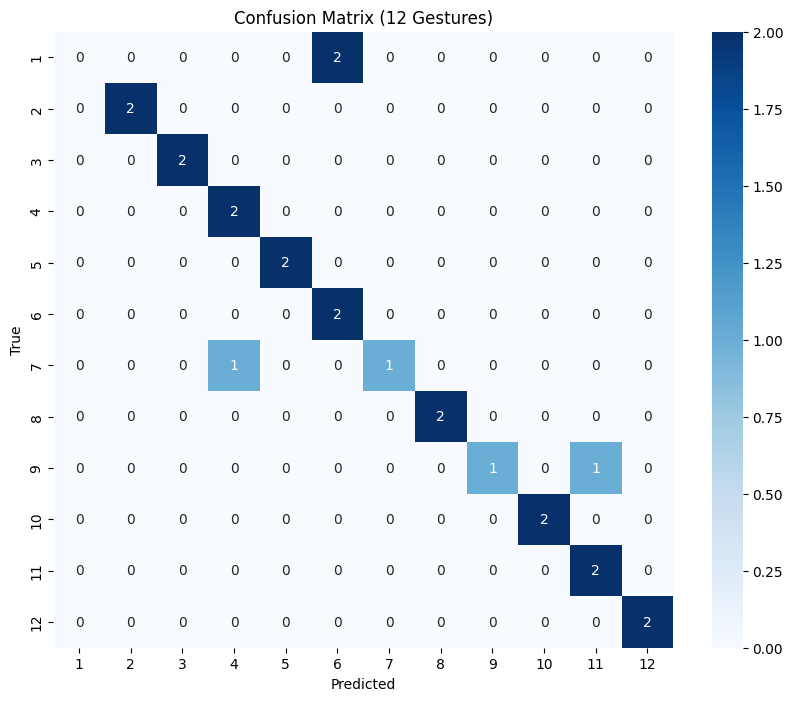

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Split into train and test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=0))

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=range(1, 13), yticklabels=range(1, 13))
plt.title("Confusion Matrix (12 Gestures)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [18]:
# Rebuild X with more features
X_enhanced = []
for g in range(1, 13):
    starts = gesture_starts[stimulus[gesture_starts] == g]
    for start in starts:
        next_idx = np.searchsorted(gesture_starts, start, side='right')
        end = gesture_starts[next_idx] if next_idx < len(gesture_starts) else len(stimulus)
        window = emg[start:end, :]  # (duration, 10)

        # Compute features per electrode
        features = []
        for electrode in range(10):
            signal = window[:, electrode]
            features.extend([
                np.mean(signal),    # Mean
                np.std(signal),     # Standard deviation
                np.min(signal),     # Min
                np.max(signal),     # Max
                np.sqrt(np.mean(signal**2))  # RMS
            ])
        X_enhanced.append(features)

X_enhanced = np.array(X_enhanced)  # (120, 50)  (10 electrodes × 5 features)
y = np.array(y)  # Same as before

print("New X shape:", X_enhanced.shape)

New X shape: (120, 50)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_enhanced, y, test_size=0.2, random_state=42, stratify=y
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           1       0.00      0.00      0.00         2
           2       1.00      0.50      0.67         2
           3       1.00      1.00      1.00         2
           4       0.67      1.00      0.80         2
           5       1.00      1.00      1.00         2
           6       0.33      0.50      0.40         2
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         2
           9       0.50      0.50      0.50         2
          10       1.00      1.00      1.00         2
          11       0.67      1.00      0.80         2
          12       1.00      1.00      1.00         2

    accuracy                           0.79        24
   macro avg       0.76      0.79      0.76        24
weighted avg       0.76      0.79      0.76        24



In [20]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print(classification_report(y_test, y_pred_knn, zero_division=0))

              precision    recall  f1-score   support

           1       0.33      0.50      0.40         2
           2       1.00      1.00      1.00         2
           3       0.33      0.50      0.40         2
           4       0.67      1.00      0.80         2
           5       1.00      1.00      1.00         2
           6       0.67      1.00      0.80         2
           7       1.00      0.50      0.67         2
           8       1.00      0.50      0.67         2
           9       1.00      0.50      0.67         2
          10       1.00      0.50      0.67         2
          11       0.67      1.00      0.80         2
          12       1.00      0.50      0.67         2

    accuracy                           0.71        24
   macro avg       0.81      0.71      0.71        24
weighted avg       0.81      0.71      0.71        24



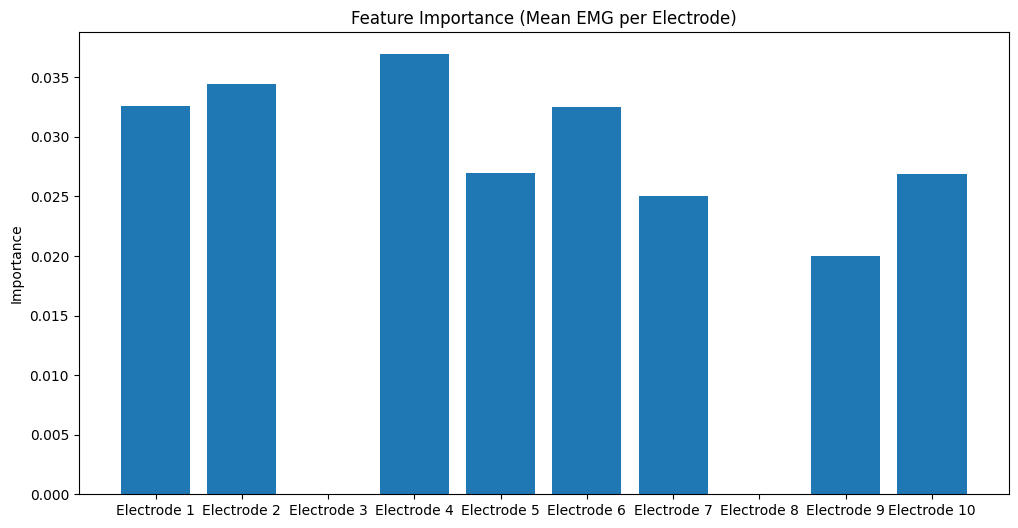

In [21]:
# Get feature importances from Random Forest
importances = clf.feature_importances_
plt.figure(figsize=(12, 6))
plt.bar(range(10), importances[:10])  # First 10 features (mean per electrode)
plt.xticks(range(10), [f"Electrode {i+1}" for i in range(10)])
plt.title("Feature Importance (Mean EMG per Electrode)")
plt.ylabel("Importance")
plt.show()

Trimming all windows to: 512 samples


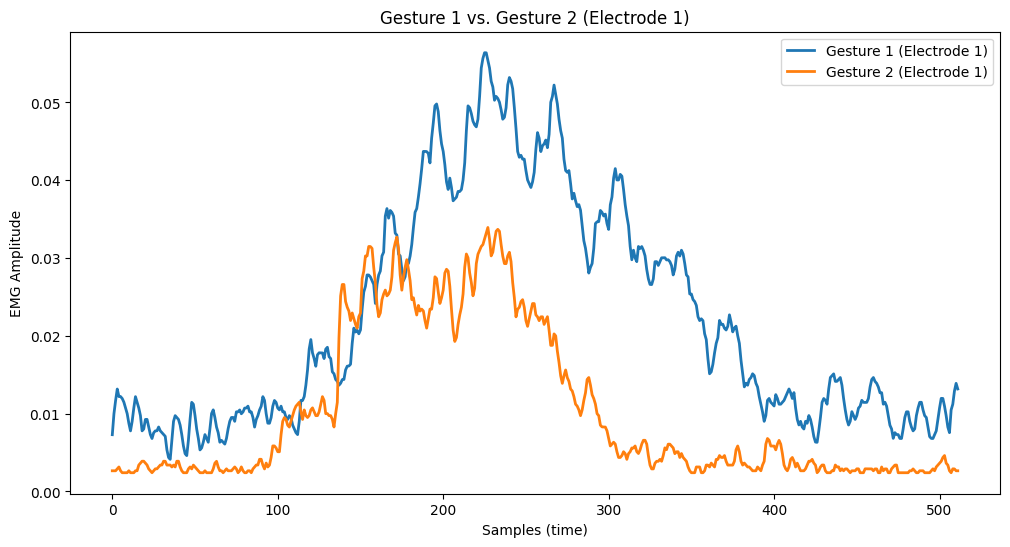

In [23]:
import numpy as np

# Get all Gesture 1 and Gesture 2 windows
gesture_1_windows = []
gesture_2_windows = []

for g in [1, 2]:
    starts = gesture_starts[stimulus[gesture_starts] == g]
    for start in starts:
        next_idx = np.searchsorted(gesture_starts, start, side='right')
        end = gesture_starts[next_idx] if next_idx < len(gesture_starts) else len(stimulus)
        window = emg[start:end, :]  # (duration, 10)
        if g == 1:
            gesture_1_windows.append(window)
        else:
            gesture_2_windows.append(window)

# Find the minimum length across all windows
min_length = min([w.shape[0] for w in gesture_1_windows + gesture_2_windows])
print("Trimming all windows to:", min_length, "samples")

# Trim all windows to min_length
gesture_1_windows = [w[:min_length, :] for w in gesture_1_windows]
gesture_2_windows = [w[:min_length, :] for w in gesture_2_windows]

# Now compute mean across repetitions
mean_gesture_1 = np.mean(gesture_1_windows, axis=0)  # (min_length, 10)
mean_gesture_2 = np.mean(gesture_2_windows, axis=0)  # (min_length, 10)

# Plot Electrode 0 for both gestures
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(mean_gesture_1[:, 0], label="Gesture 1 (Electrode 1)", linewidth=2)
plt.plot(mean_gesture_2[:, 0], label="Gesture 2 (Electrode 1)", linewidth=2)
plt.xlabel("Samples (time)")
plt.ylabel("EMG Amplitude")
plt.title("Gesture 1 vs. Gesture 2 (Electrode 1)")
plt.legend()
plt.show()


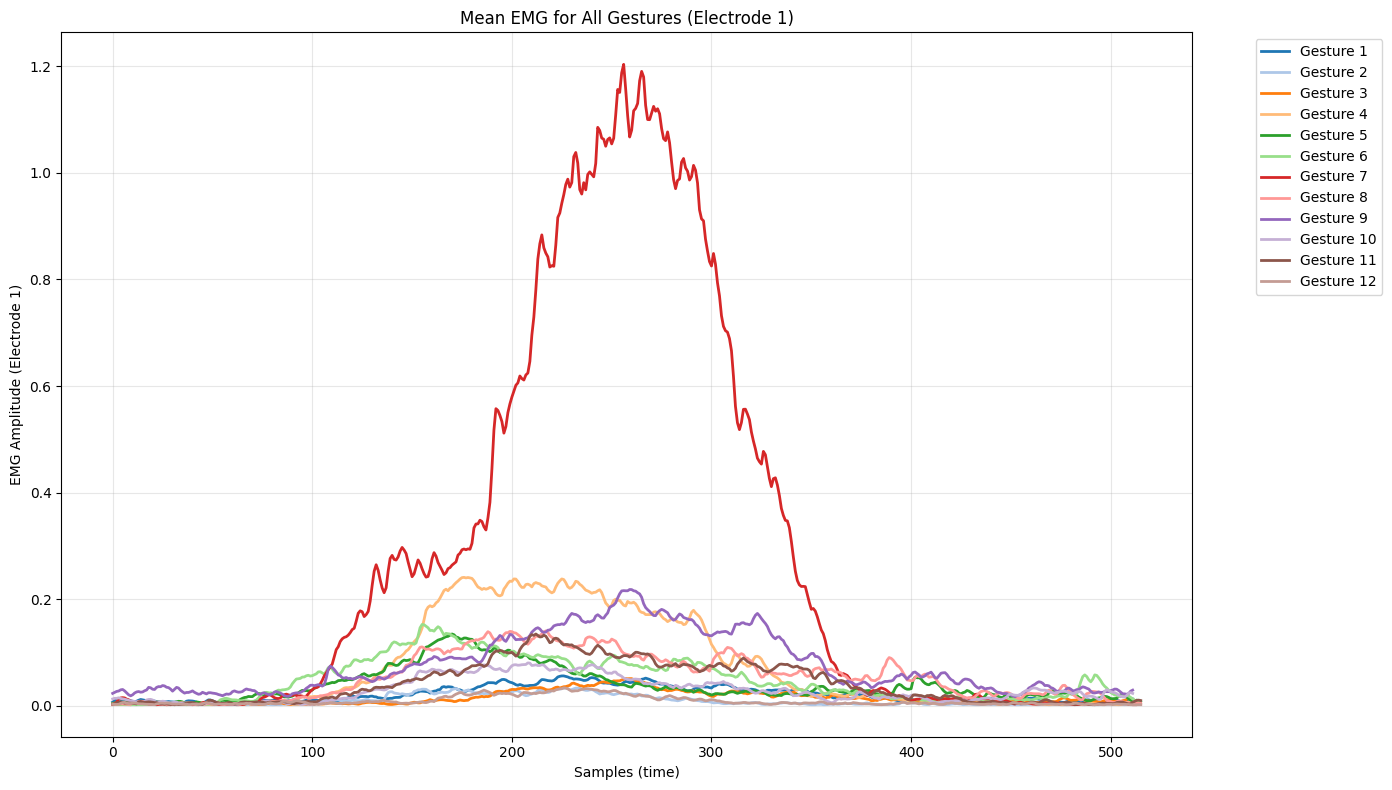

In [24]:
import matplotlib.pyplot as plt

# Define colors for each gesture
colors = plt.cm.tab20.colors  # 20 distinct colors (enough for 12 gestures)

plt.figure(figsize=(14, 8))

# For each gesture (1-12), compute mean window and plot
for g in range(1, 13):
    # Get all windows for this gesture
    windows = []
    starts = gesture_starts[stimulus[gesture_starts] == g]
    for start in starts:
        next_idx = np.searchsorted(gesture_starts, start, side='right')
        end = gesture_starts[next_idx] if next_idx < len(gesture_starts) else len(stimulus)
        window = emg[start:end, :]
        windows.append(window)

    # Trim all windows to the same length (min length for this gesture)
    min_len = min([w.shape[0] for w in windows])
    windows = [w[:min_len, :] for w in windows]

    # Compute mean across repetitions for Electrode 0 (first electrode)
    mean_window = np.mean(windows, axis=0)  # (min_len, 10)
    electrode_0 = mean_window[:, 0]  # First electrode

    # Plot
    plt.plot(electrode_0, label=f"Gesture {g}", color=colors[g-1], linewidth=2)

plt.xlabel("Samples (time)")
plt.ylabel("EMG Amplitude (Electrode 1)")
plt.title("Mean EMG for All Gestures (Electrode 1)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Legend outside plot
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
# Rebuild X with 3 sub-windows per gesture
X_subwindows = []
y_subwindows = []

for g in range(1, 13):
    starts = gesture_starts[stimulus[gesture_starts] == g]
    for start in starts:
        next_idx = np.searchsorted(gesture_starts, start, side='right')
        end = gesture_starts[next_idx] if next_idx < len(gesture_starts) else len(stimulus)
        window = emg[start:end, :]  # (duration, 10)

        # Split into 3 equal parts
        n = window.shape[0]
        split1 = window[:n//3, :]
        split2 = window[n//3:2*n//3, :]
        split3 = window[2*n//3:, :]

        # Compute mean per electrode for each split
        features = [
            np.mean(split1, axis=0),  # First third (10 features)
            np.mean(split2, axis=0),  # Second third (10 features)
            np.mean(split3, axis=0)   # Third third (10 features)
        ]
        features = np.concatenate(features)  # (30,)
        X_subwindows.append(features)
        y_subwindows.append(g)

X_subwindows = np.array(X_subwindows)  # (120, 30)
y_subwindows = np.array(y_subwindows)

print("New X shape:", X_subwindows.shape)

New X shape: (120, 30)


In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_subwindows, y_subwindows, test_size=0.2, random_state=42, stratify=y_subwindows
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           1       0.67      1.00      0.80         2
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         2
           4       0.67      1.00      0.80         2
           5       1.00      1.00      1.00         2
           6       1.00      0.50      0.67         2
           7       1.00      0.50      0.67         2
           8       1.00      0.50      0.67         2
           9       0.50      0.50      0.50         2
          10       1.00      1.00      1.00         2
          11       0.67      1.00      0.80         2
          12       1.00      1.00      1.00         2

    accuracy                           0.83        24
   macro avg       0.87      0.83      0.83        24
weighted avg       0.87      0.83      0.83        24

